In [1]:
from pathlib import Path
import shutil
import time

def clean_xpidon_outputs(
    project_root=".",
    backup=True,
    dry_run=True,
):
    """
    Clean old XPIDON training outputs before a new notebook training run.

    Use this BEFORE training.
    Do NOT run this after training and before plotting, otherwise models/loss files will be deleted.

    Parameters
    ----------
    project_root : str
        Project root path. Usually "." if notebook is opened inside XPIDON-Composites.
    backup : bool
        If True, backup current outputs/ and root-level model pkl files before cleaning.
    dry_run : bool
        If True, only print what would be deleted. Set False to actually clean.
    """

    root = Path(project_root).resolve()

    # Safety check: avoid deleting files from wrong directory
    expected_files = ["main.py", "phy_params.json", "exp_params.json", "train_params.json"]
    existing_expected = [f for f in expected_files if (root / f).exists()]

    if len(existing_expected) < 2:
        raise RuntimeError(
            f"Project root may be wrong: {root}\n"
            "Please run this from XPIDON-Composites project root or set project_root correctly."
        )

    print(f"Project root: {root}")
    print(f"Dry run: {dry_run}")
    print(f"Backup: {backup}")

    # Folders generated by training/plotting
    output_subdirs = [
        root / "outputs" / "models",
        root / "outputs" / "loss_data",
        root / "outputs" / "figures",
        root / "outputs" / "predictions",
    ]

    # Root-level files generated by train.py
    root_patterns = [
        "xpidon_class_*_T.pkl",
        "xpidon_class_*_a.pkl",
        "T_temp.pkl",
        "a_temp.pkl",
    ]

    files_to_delete = []
    dirs_to_clean = []

    for folder in output_subdirs:
        folder.mkdir(parents=True, exist_ok=True)
        dirs_to_clean.append(folder)
        for item in folder.iterdir():
            files_to_delete.append(item)

    for pattern in root_patterns:
        files_to_delete.extend(root.glob(pattern))

    files_to_delete = sorted(set(files_to_delete))

    print("\nFiles/folders that will be cleaned:")
    if not files_to_delete:
        print("  Nothing to clean.")
    else:
        for p in files_to_delete:
            print(" ", p.relative_to(root))

    if dry_run:
        print("\nDry run only. Nothing was deleted.")
        print("Run clean_xpidon_outputs(dry_run=False) to actually clean.")
        return

    # Optional backup
    if backup and files_to_delete:
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        backup_dir = root / f"outputs_backup_{timestamp}"
        backup_dir.mkdir(parents=True, exist_ok=True)

        print(f"\nCreating backup: {backup_dir.name}")

        # Backup outputs folder
        outputs_dir = root / "outputs"
        if outputs_dir.exists():
            shutil.copytree(outputs_dir, backup_dir / "outputs", dirs_exist_ok=True)

        # Backup root pkl files
        root_pkl_backup = backup_dir / "root_pkl_files"
        root_pkl_backup.mkdir(exist_ok=True)

        for pattern in root_patterns:
            for file in root.glob(pattern):
                if file.is_file():
                    shutil.copy2(file, root_pkl_backup / file.name)

    # Delete contents
    for p in files_to_delete:
        if p.exists():
            if p.is_file() or p.is_symlink():
                p.unlink()
            elif p.is_dir():
                shutil.rmtree(p)

    # Recreate output folders
    for folder in output_subdirs:
        folder.mkdir(parents=True, exist_ok=True)

    print("\nClean complete.")

In [2]:
clean_xpidon_outputs(dry_run=True)

Project root: /Users/luzhang/Projects/XPIDON-Composites
Dry run: True
Backup: True

Files/folders that will be cleaned:
  T_temp.pkl
  a_temp.pkl
  outputs/figures/doc_network_loss.png
  outputs/figures/final_temperature_doc_prediction.png
  outputs/figures/temperature_network_loss.png
  outputs/loss_data/loss_history_03333.pkl
  outputs/loss_data/loss_history_06667.pkl
  outputs/loss_data/loss_history_10000.pkl
  outputs/loss_data/loss_history_merged.pkl
  outputs/models/xpidon_class_03333_T.pkl
  outputs/models/xpidon_class_03333_a.pkl
  outputs/models/xpidon_class_06667_T.pkl
  outputs/models/xpidon_class_06667_a.pkl
  outputs/models/xpidon_class_10000_T.pkl
  outputs/models/xpidon_class_10000_a.pkl
  outputs/predictions/final_temperature_doc_prediction.csv
  outputs/predictions/final_temperature_doc_prediction.pkl
  xpidon_class_00_T.pkl
  xpidon_class_00_a.pkl
  xpidon_class_03333333333333333_T.pkl
  xpidon_class_03333333333333333_a.pkl
  xpidon_class_06666666666666666_T.pkl
  xpi

In [3]:
clean_xpidon_outputs(dry_run=False, backup=True)

Project root: /Users/luzhang/Projects/XPIDON-Composites
Dry run: False
Backup: True

Files/folders that will be cleaned:
  T_temp.pkl
  a_temp.pkl
  outputs/figures/doc_network_loss.png
  outputs/figures/final_temperature_doc_prediction.png
  outputs/figures/temperature_network_loss.png
  outputs/loss_data/loss_history_03333.pkl
  outputs/loss_data/loss_history_06667.pkl
  outputs/loss_data/loss_history_10000.pkl
  outputs/loss_data/loss_history_merged.pkl
  outputs/models/xpidon_class_03333_T.pkl
  outputs/models/xpidon_class_03333_a.pkl
  outputs/models/xpidon_class_06667_T.pkl
  outputs/models/xpidon_class_06667_a.pkl
  outputs/models/xpidon_class_10000_T.pkl
  outputs/models/xpidon_class_10000_a.pkl
  outputs/predictions/final_temperature_doc_prediction.csv
  outputs/predictions/final_temperature_doc_prediction.pkl
  xpidon_class_00_T.pkl
  xpidon_class_00_a.pkl
  xpidon_class_03333333333333333_T.pkl
  xpidon_class_03333333333333333_a.pkl
  xpidon_class_06666666666666666_T.pkl
  xp

In [4]:
from utils.phy_params import PhyParams
from utils.exp_params import ExpParams
from utils.train_params import TrainParams
from utils.air_temp import Temp_air
from utils.data_utils import DataGenerator, generate_training_data
from trainer.train import train
from models.pidon import XPIDON
from loss.loss import XPIDONLoss

Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!


Metal device set to: Apple M4 Pro

systemMemory: 24.00 GB
maxCacheSize: 8.00 GB



W0000 00:00:1782477024.713146 4683186 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1782477024.724677 4683186 service.cc:145] XLA service 0x11f2d9510 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782477024.724690 4683186 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1782477024.725868 4683186 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1782477024.725879 4683186 mps_client.cc:384] XLA backend will use up to 17179410432 bytes on device 0 for SimpleAllocator.


In [ ]:
params = PhyParams('phy_params.json')
exp_params = ExpParams('exp_params.json')
train_params = TrainParams('train_params.json')
init_sub_domain = 5
Tolerance_level =  1.00e-03
m_inp = 9
branch_layers = [m_inp, 50, 50, 50, 100]
trunk_layers =  [2, 50, 50, 50, 50, 50, 100]
nomad_layers_T = [100, 50, 50, 50, 50, 1]


--- Processing Sub-domain: 1/5 ---
Time range: 0.00 to 3760.00 seconds


Training Progress:  20%|███████████████████████████████████▍                                                                                                                                             | 10/50 [00:29<01:46,  2.67s/it, Status=** Training T **, Loss T=4.43e+00, Loss a=1.10e-03, ICs T=4.71e-01, ICs tool=4.71e-01, ICs Alpha=5.49e-05, BCs Bot=3.30e-01, BCs Top=2.28e-01, PDE Part=6.89e-01, PDE Tool=1.31e-03, Cure Part=1.04e-03, INF=1.05e-04, FLUX=8.18e-03, T lr=1.00e-03, a lr=9.48e-04]

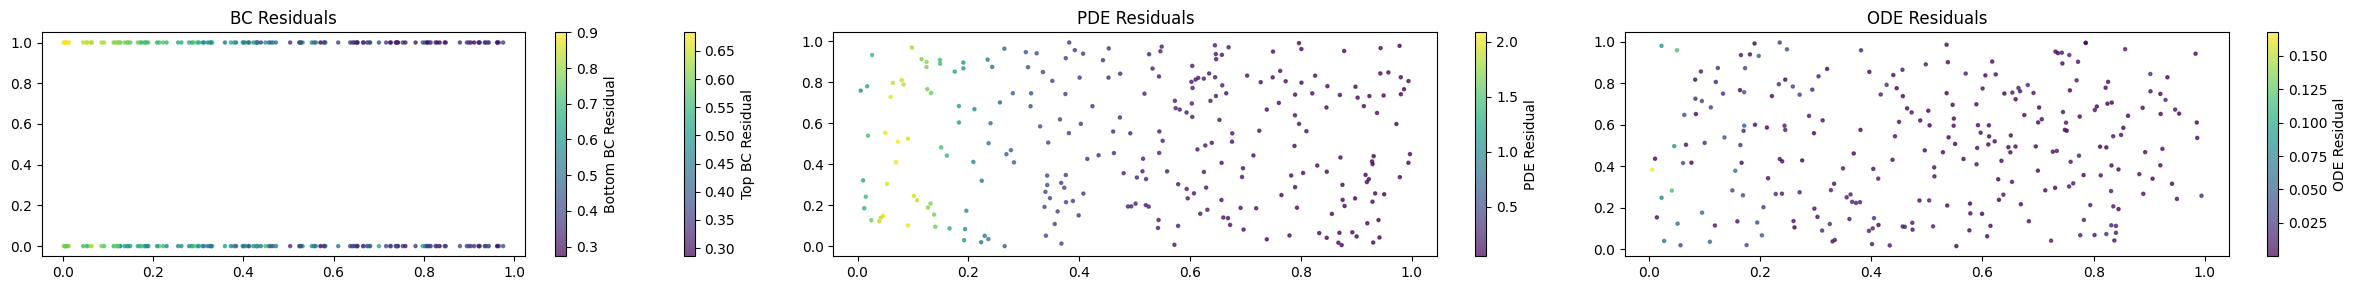

Training Progress:  40%|██████████████████████████████████████████████████████████████████████▊                                                                                                          | 20/50 [01:11<01:56,  3.87s/it, Status=** Training a **, Loss T=7.08e-03, Loss a=1.44e+00, ICs T=1.87e-04, ICs tool=1.80e-04, ICs Alpha=5.65e-05, BCs Bot=5.96e-04, BCs Top=5.45e-04, PDE Part=1.95e-04, PDE Tool=2.99e-04, Cure Part=1.44e+00, INF=3.48e-04, FLUX=1.70e-04, T lr=9.48e-04, a lr=9.48e-04]

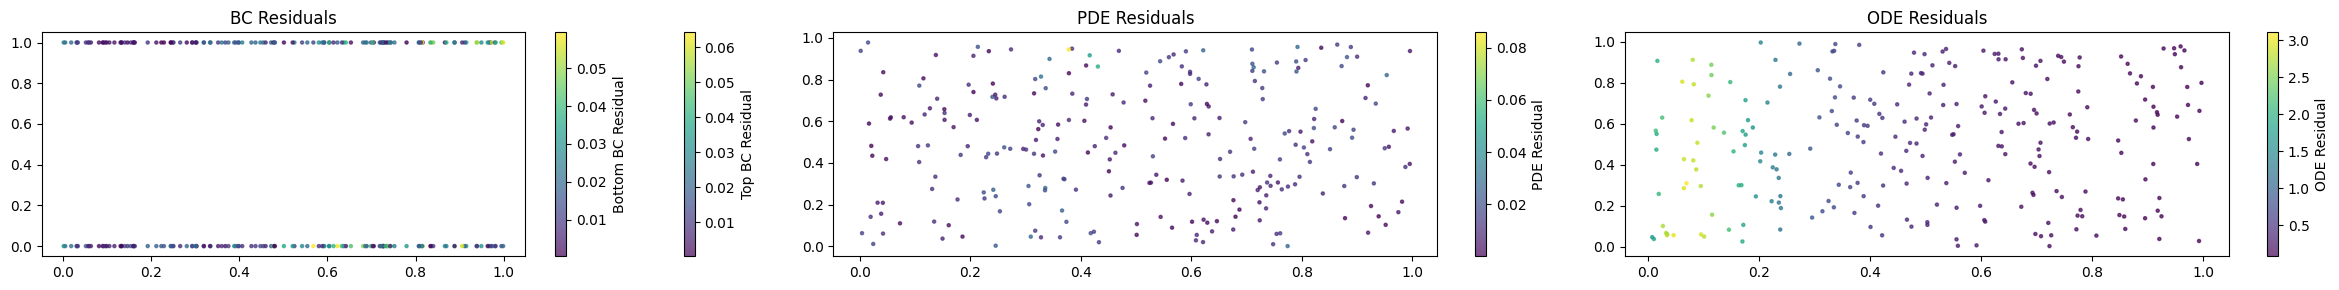

Training Progress:  60%|██████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                                                      | 30/50 [01:38<00:54,  2.72s/it, Status=** Training T **, Loss T=7.29e-03, Loss a=5.64e-05, ICs T=1.70e-04, ICs tool=1.78e-04, ICs Alpha=4.13e-06, BCs Bot=5.86e-04, BCs Top=5.67e-04, PDE Part=2.00e-04, PDE Tool=3.01e-04, Cure Part=5.22e-05, INF=4.97e-04, FLUX=1.81e-04, T lr=9.48e-04, a lr=8.99e-04]

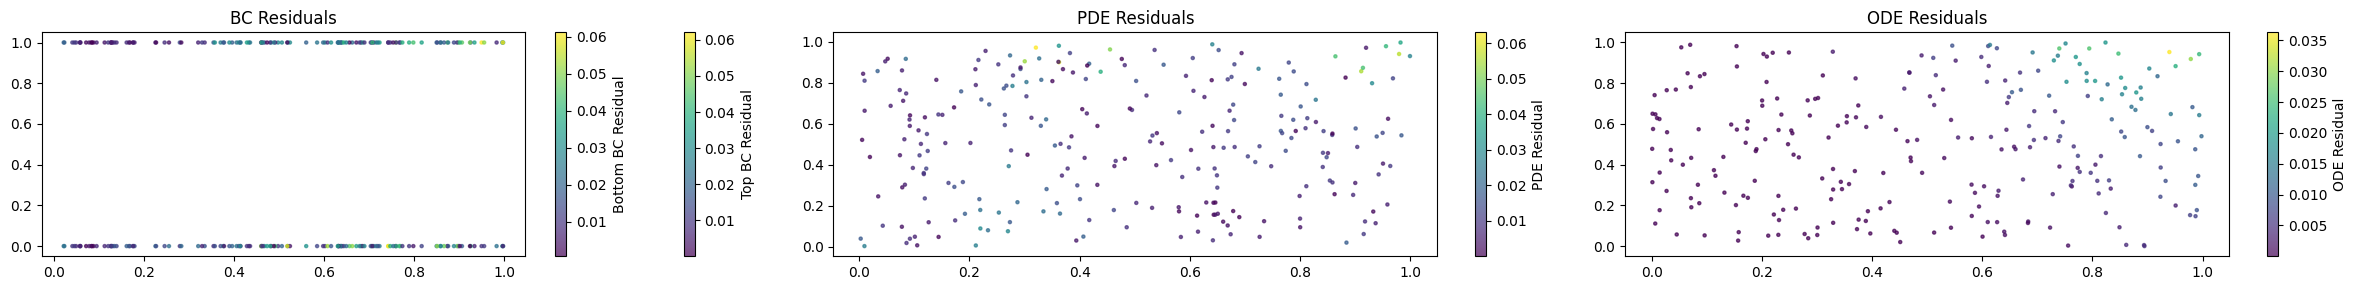

Training Progress:  80%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                   | 40/50 [02:17<00:38,  3.90s/it, Status=** Training a **, Loss T=2.63e-03, Loss a=4.24e-05, ICs T=6.70e-05, ICs tool=1.01e-04, ICs Alpha=4.13e-06, BCs Bot=2.04e-04, BCs Top=1.72e-04, PDE Part=9.20e-05, PDE Tool=1.78e-04, Cure Part=3.83e-05, INF=2.25e-04, FLUX=8.29e-05, T lr=8.99e-04, a lr=8.99e-04]

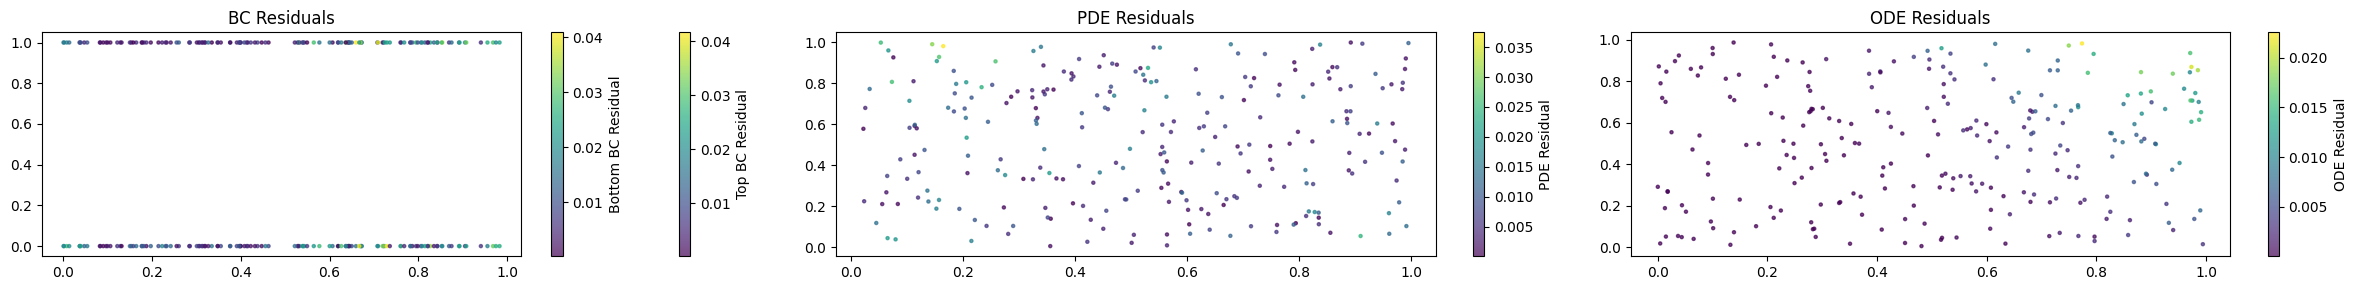

Training Progress: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [02:45<00:00,  3.31s/it, Status=** Training T **, Loss T=2.49e-03, Loss a=4.83e-05, ICs T=7.11e-05, ICs tool=9.78e-05, ICs Alpha=3.30e-06, BCs Bot=1.87e-04, BCs Top=1.61e-04, PDE Part=1.04e-04, PDE Tool=1.75e-04, Cure Part=4.50e-05, INF=2.51e-04, FLUX=5.79e-05, T lr=8.99e-04, a lr=8.52e-04]



Models saved for converged subdomain 0.00 - 0.20
Saved as xpidon_class_02_T.pkl and xpidon_class_02_a.pkl

Models saved for converged subdomain 0.00 - 0.20
Saved as outputs/models/xpidon_class_02000_T.pkl and outputs/models/xpidon_class_02000_a.pkl
Loss history saved as outputs/loss_data/loss_history_02000.pkl

--- Processing Sub-domain: 2/5 ---
Time range: 3760.00 to 7520.00 seconds
Loaded pre-trained parameters from xpidon_class_02_T.pkl and xpidon_class_02_a.pkl


Training Progress:  20%|███████████████████████████████████▍                                                                                                                                             | 10/50 [00:29<01:50,  2.77s/it, Status=** Training T **, Loss T=2.34e+00, Loss a=1.11e-03, ICs T=1.77e-01, ICs tool=2.23e-01, ICs Alpha=2.14e-04, BCs Bot=1.61e-01, BCs Top=9.11e-02, PDE Part=6.71e-01, PDE Tool=1.31e-03, Cure Part=8.92e-04, INF=1.05e-04, FLUX=8.18e-03, T lr=1.00e-03, a lr=9.48e-04]

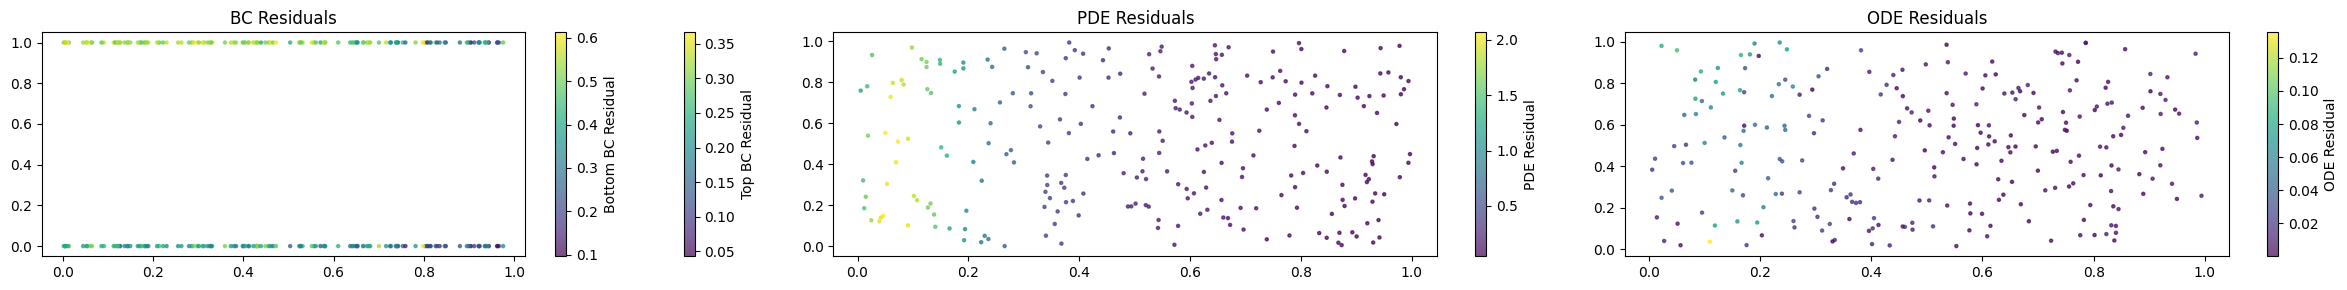

Training Progress:  40%|██████████████████████████████████████████████████████████████████████▊                                                                                                          | 20/50 [01:11<02:01,  4.04s/it, Status=** Training a **, Loss T=1.13e-02, Loss a=1.45e+00, ICs T=1.80e-04, ICs tool=5.01e-04, ICs Alpha=2.23e-04, BCs Bot=8.50e-04, BCs Top=8.14e-04, PDE Part=3.98e-04, PDE Tool=8.99e-04, Cure Part=1.45e+00, INF=3.82e-04, FLUX=6.61e-04, T lr=9.48e-04, a lr=9.48e-04]

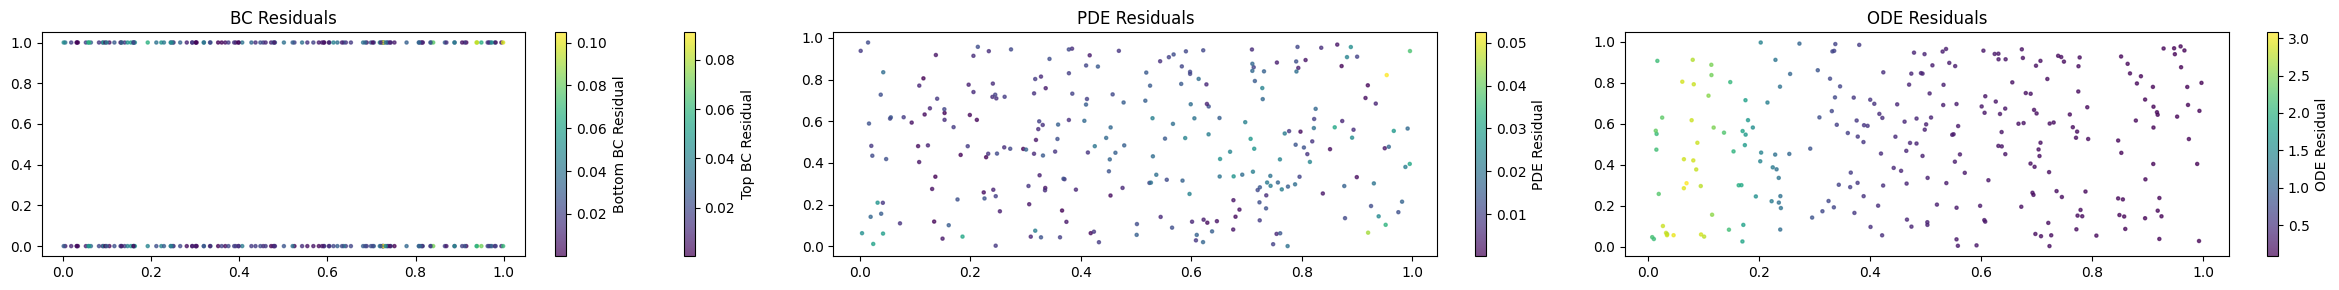

Training Progress:  60%|██████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                                                      | 30/50 [01:39<00:56,  2.81s/it, Status=** Training T **, Loss T=1.21e-02, Loss a=3.34e-03, ICs T=1.81e-04, ICs tool=6.30e-04, ICs Alpha=4.26e-07, BCs Bot=8.25e-04, BCs Top=8.18e-04, PDE Part=1.31e-03, PDE Tool=7.85e-04, Cure Part=3.34e-03, INF=3.54e-04, FLUX=6.38e-04, T lr=9.48e-04, a lr=8.99e-04]

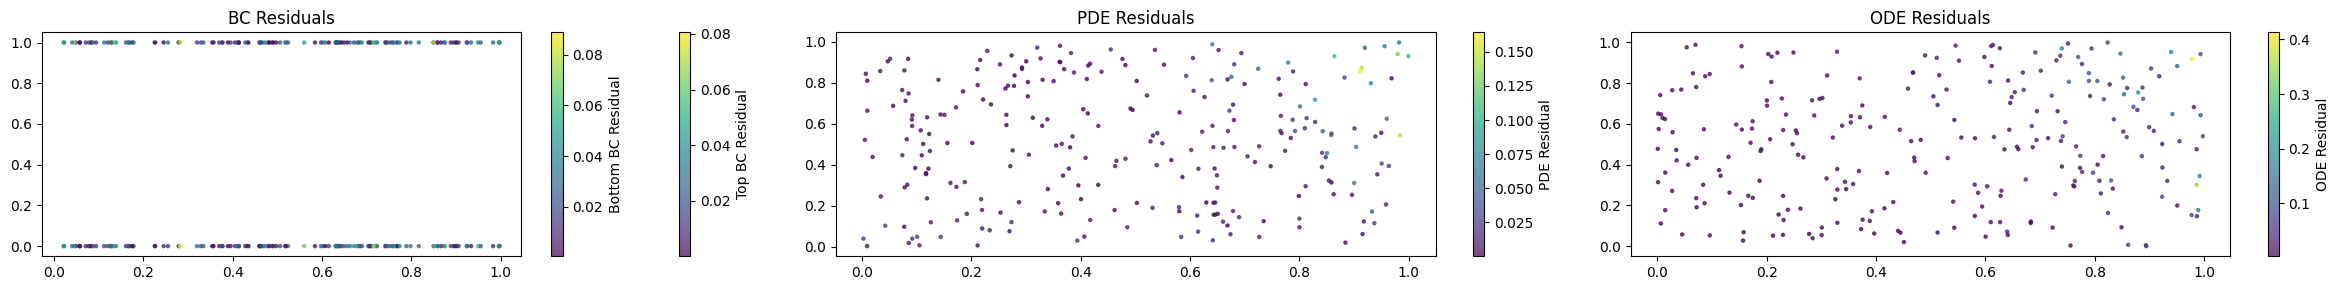

Training Progress:  80%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                   | 40/50 [02:20<00:40,  4.04s/it, Status=** Training a **, Loss T=5.94e-03, Loss a=2.83e-03, ICs T=1.49e-04, ICs tool=2.00e-04, ICs Alpha=4.26e-07, BCs Bot=4.48e-04, BCs Top=3.04e-04, PDE Part=4.90e-04, PDE Tool=4.63e-04, Cure Part=2.83e-03, INF=2.13e-04, FLUX=6.68e-04, T lr=8.99e-04, a lr=8.99e-04]

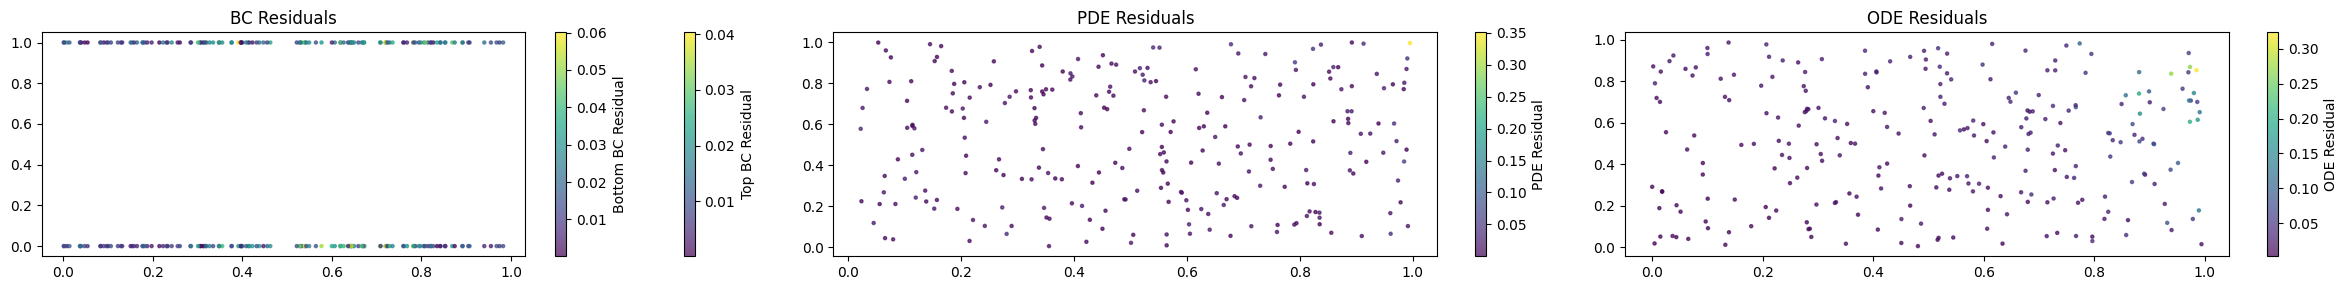

Training Progress: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [02:48<00:00,  3.38s/it, Status=** Training T **, Loss T=5.61e-03, Loss a=4.63e-03, ICs T=1.57e-04, ICs tool=2.01e-04, ICs Alpha=1.29e-06, BCs Bot=4.24e-04, BCs Top=3.60e-04, PDE Part=2.66e-04, PDE Tool=3.25e-04, Cure Part=4.62e-03, INF=2.25e-04, FLUX=5.16e-04, T lr=8.99e-04, a lr=8.52e-04]



Models saved for converged subdomain 0.20 - 0.40
Saved as xpidon_class_04_T.pkl and xpidon_class_04_a.pkl

Models saved for converged subdomain 0.20 - 0.40
Saved as outputs/models/xpidon_class_04000_T.pkl and outputs/models/xpidon_class_04000_a.pkl
Loss history saved as outputs/loss_data/loss_history_04000.pkl

--- Processing Sub-domain: 3/5 ---
Time range: 7520.00 to 11280.00 seconds
Loaded pre-trained parameters from xpidon_class_04_T.pkl and xpidon_class_04_a.pkl


Training Progress:  20%|███████████████████████████████████▍                                                                                                                                             | 10/50 [00:29<01:51,  2.79s/it, Status=** Training T **, Loss T=1.03e+00, Loss a=6.40e-04, ICs T=7.20e-02, ICs tool=9.85e-02, ICs Alpha=3.58e-04, BCs Bot=2.96e-02, BCs Top=5.11e-03, PDE Part=6.81e-01, PDE Tool=1.31e-03, Cure Part=2.82e-04, INF=1.05e-04, FLUX=8.18e-03, T lr=1.00e-03, a lr=9.48e-04]

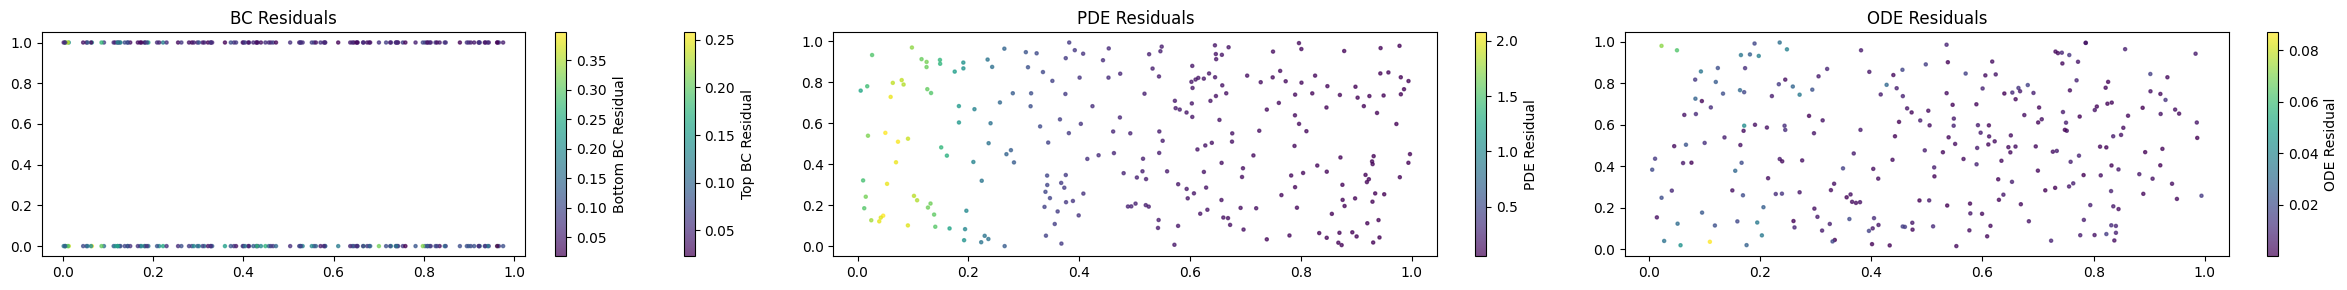

Training Progress:  40%|██████████████████████████████████████████████████████████████████████▊                                                                                                          | 20/50 [01:12<02:02,  4.09s/it, Status=** Training a **, Loss T=7.56e-03, Loss a=1.12e+00, ICs T=3.40e-04, ICs tool=4.45e-04, ICs Alpha=3.71e-04, BCs Bot=5.68e-04, BCs Top=4.58e-04, PDE Part=9.14e-04, PDE Tool=4.15e-04, Cure Part=1.12e+00, INF=1.13e-04, FLUX=2.06e-04, T lr=9.48e-04, a lr=9.48e-04]

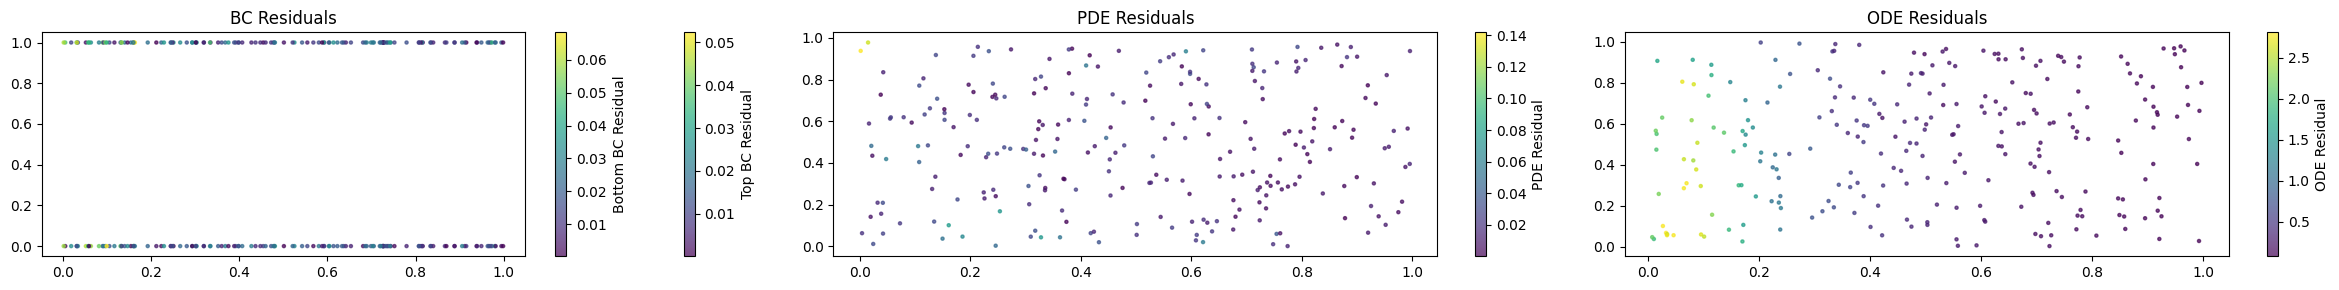

Training Progress:  60%|██████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                                                      | 30/50 [01:40<00:56,  2.82s/it, Status=** Training T **, Loss T=1.64e-01, Loss a=1.12e-03, ICs T=2.49e-04, ICs tool=3.99e-04, ICs Alpha=1.04e-04, BCs Bot=1.32e-03, BCs Top=7.10e-04, PDE Part=1.53e-01, PDE Tool=4.03e-04, Cure Part=1.01e-03, INF=1.39e-04, FLUX=3.06e-04, T lr=9.48e-04, a lr=8.99e-04]

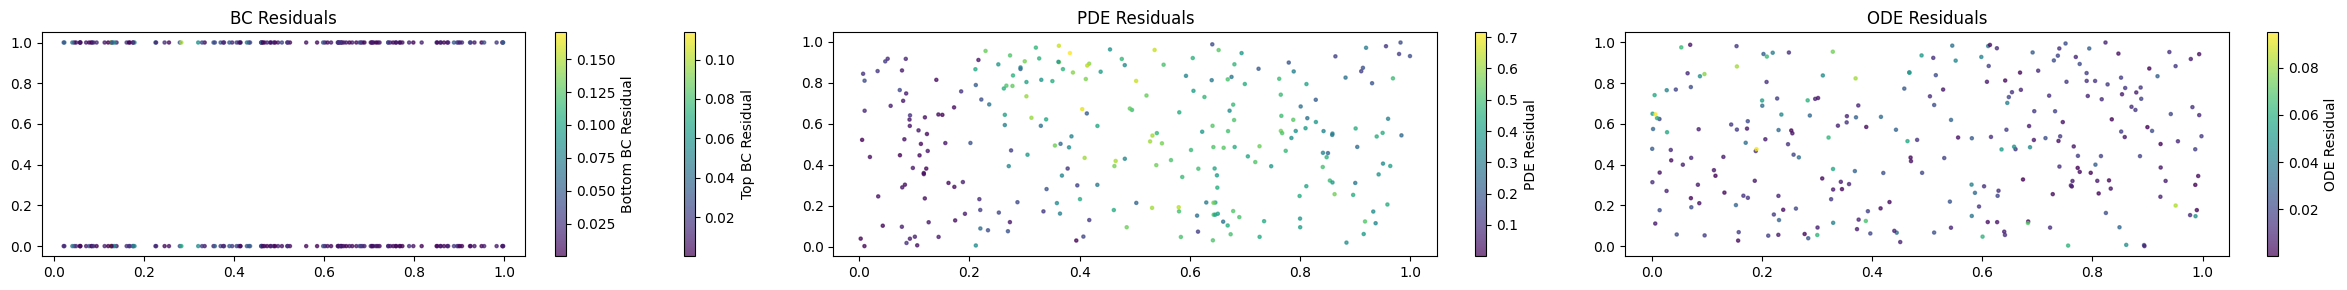

Training Progress:  80%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                   | 40/50 [02:22<00:40,  4.08s/it, Status=** Training a **, Loss T=6.89e-03, Loss a=7.94e-02, ICs T=3.52e-04, ICs tool=1.14e-04, ICs Alpha=1.18e-04, BCs Bot=3.78e-04, BCs Top=4.13e-04, PDE Part=1.20e-03, PDE Tool=2.31e-04, Cure Part=7.93e-02, INF=8.75e-04, FLUX=1.65e-04, T lr=8.99e-04, a lr=8.99e-04]

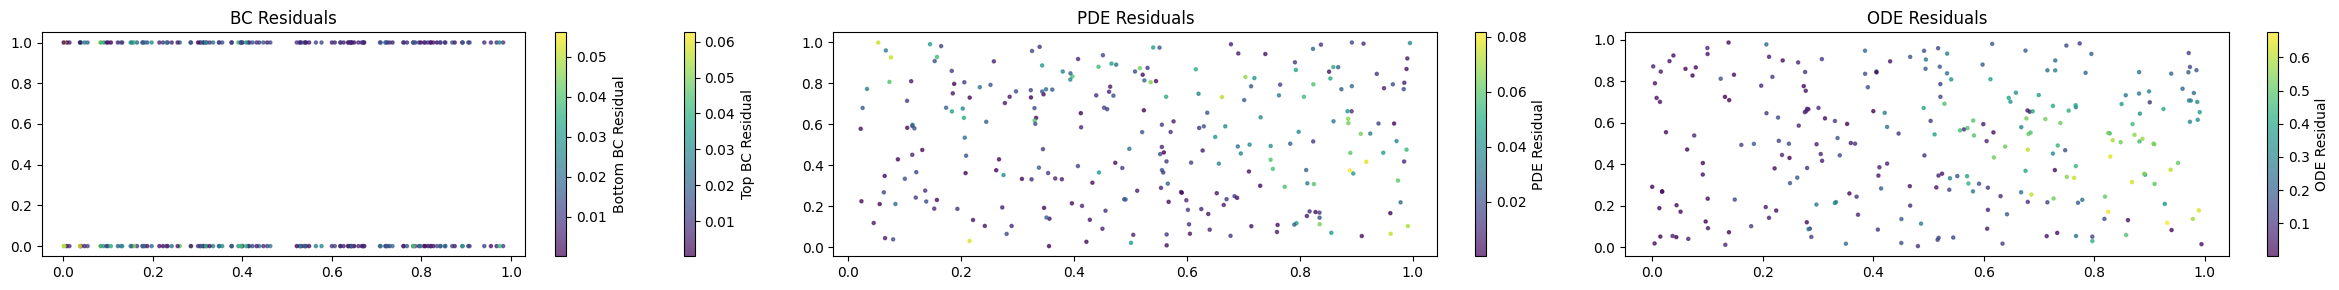

Training Progress: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [02:50<00:00,  3.41s/it, Status=** Training T **, Loss T=1.25e-02, Loss a=4.85e-04, ICs T=4.96e-04, ICs tool=1.14e-04, ICs Alpha=1.01e-04, BCs Bot=2.92e-04, BCs Top=2.98e-04, PDE Part=7.59e-03, PDE Tool=2.64e-04, Cure Part=3.84e-04, INF=8.96e-04, FLUX=2.20e-04, T lr=8.99e-04, a lr=8.52e-04]



Models saved for converged subdomain 0.40 - 0.60
Saved as xpidon_class_06000000000000001_T.pkl and xpidon_class_06000000000000001_a.pkl

Models saved for converged subdomain 0.40 - 0.60
Saved as outputs/models/xpidon_class_06000_T.pkl and outputs/models/xpidon_class_06000_a.pkl
Loss history saved as outputs/loss_data/loss_history_06000.pkl

--- Processing Sub-domain: 4/5 ---
Time range: 11280.00 to 15040.00 seconds
Loaded pre-trained parameters from xpidon_class_06000000000000001_T.pkl and xpidon_class_06000000000000001_a.pkl


Training Progress:  20%|███████████████████████████████████▍                                                                                                                                             | 10/50 [00:30<01:54,  2.86s/it, Status=** Training T **, Loss T=2.26e-01, Loss a=2.25e-04, ICs T=2.50e-03, ICs tool=8.43e-03, ICs Alpha=1.88e-04, BCs Bot=2.79e-02, BCs Top=3.82e-03, PDE Part=4.73e-02, PDE Tool=1.31e-03, Cure Part=3.70e-05, INF=1.05e-04, FLUX=8.18e-03, T lr=1.00e-03, a lr=9.48e-04]

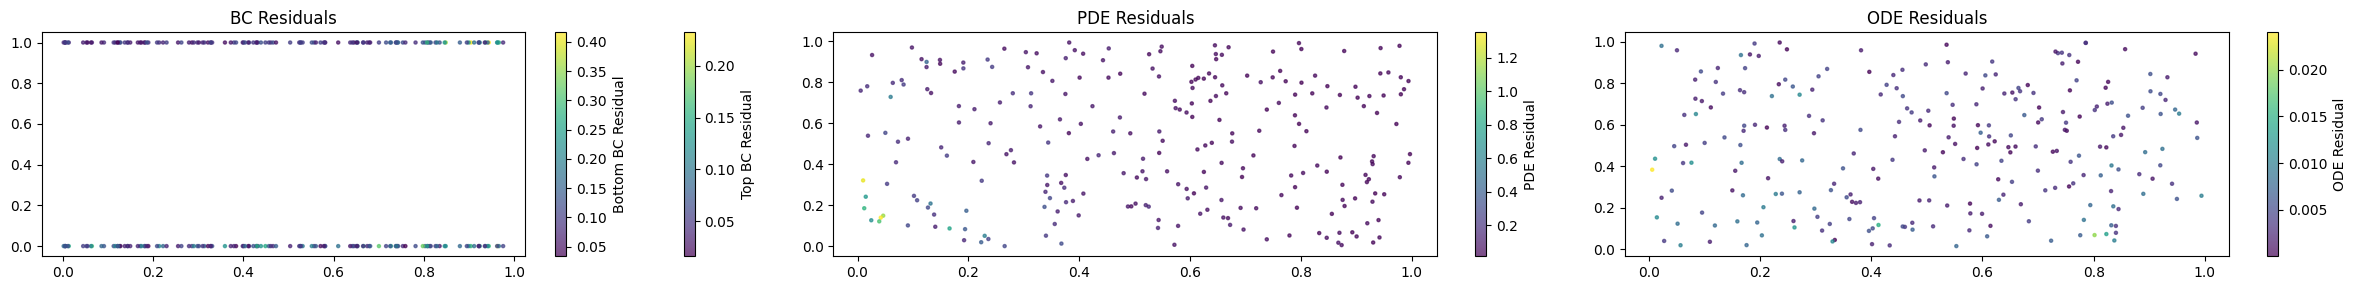

Training Progress:  40%|██████████████████████████████████████████████████████████████████████▊                                                                                                          | 20/50 [01:13<02:03,  4.12s/it, Status=** Training a **, Loss T=8.43e-03, Loss a=3.76e-02, ICs T=1.54e-04, ICs tool=3.17e-04, ICs Alpha=1.89e-04, BCs Bot=6.53e-04, BCs Top=6.51e-04, PDE Part=2.85e-04, PDE Tool=6.10e-04, Cure Part=3.74e-02, INF=3.71e-04, FLUX=1.71e-04, T lr=9.48e-04, a lr=9.48e-04]

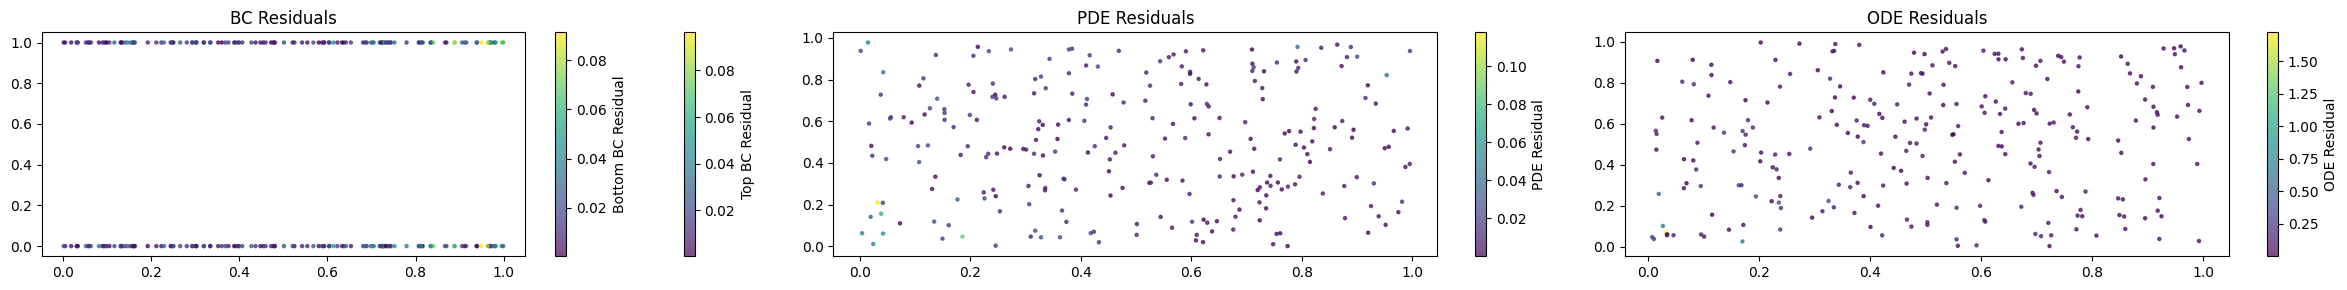

Training Progress:  60%|██████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                                                      | 30/50 [01:42<00:57,  2.89s/it, Status=** Training T **, Loss T=1.65e-02, Loss a=2.92e-04, ICs T=1.64e-04, ICs tool=4.38e-04, ICs Alpha=5.68e-05, BCs Bot=6.20e-04, BCs Top=7.70e-04, PDE Part=7.62e-03, PDE Tool=7.10e-04, Cure Part=2.36e-04, INF=4.15e-04, FLUX=1.83e-04, T lr=9.48e-04, a lr=8.99e-04]

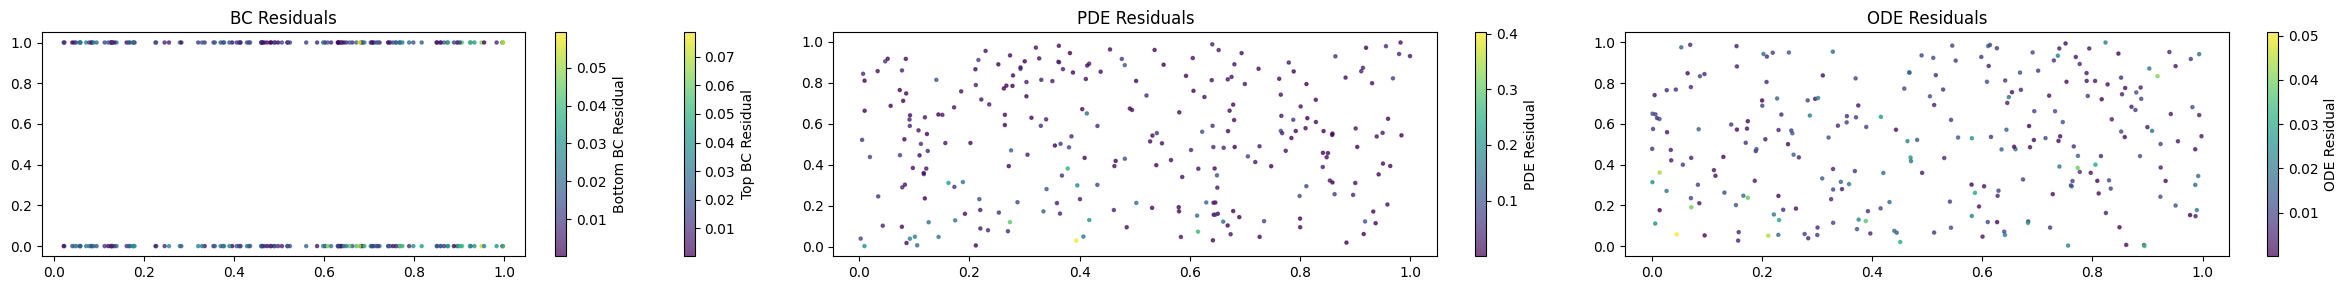

Training Progress:  80%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                   | 40/50 [02:24<00:41,  4.13s/it, Status=** Training a **, Loss T=5.18e-03, Loss a=2.67e-03, ICs T=1.49e-04, ICs tool=1.60e-04, ICs Alpha=7.64e-05, BCs Bot=5.02e-04, BCs Top=2.56e-04, PDE Part=2.74e-04, PDE Tool=4.72e-04, Cure Part=2.59e-03, INF=9.77e-05, FLUX=2.42e-04, T lr=8.99e-04, a lr=8.99e-04]

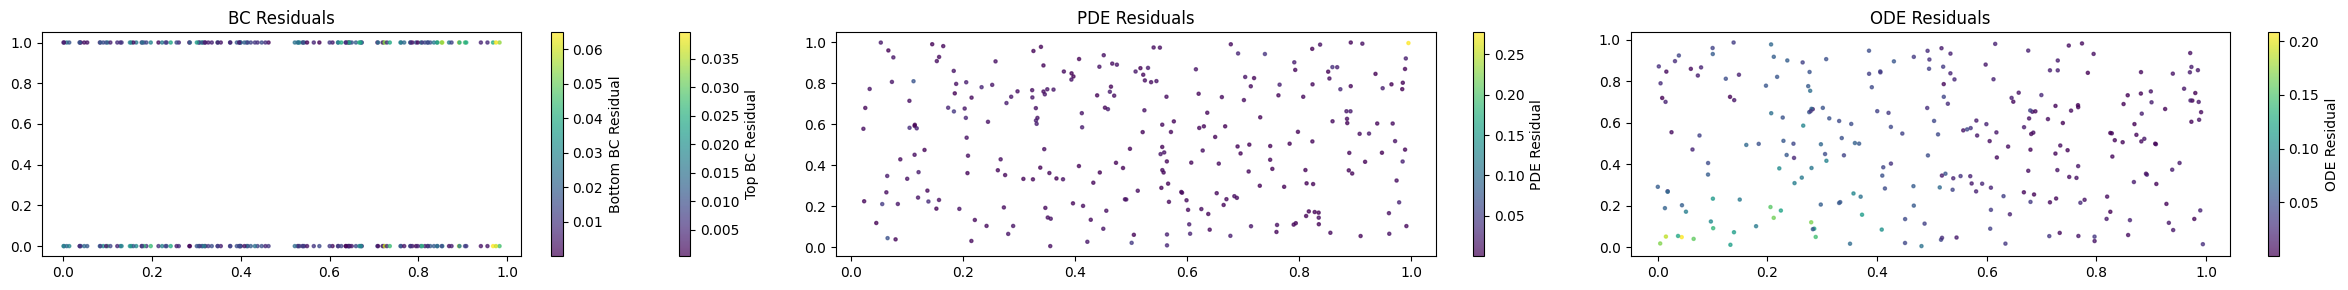

Training Progress: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [02:53<00:00,  3.48s/it, Status=** Training T **, Loss T=5.38e-03, Loss a=1.61e-04, ICs T=1.45e-04, ICs tool=1.81e-04, ICs Alpha=2.34e-05, BCs Bot=5.12e-04, BCs Top=2.48e-04, PDE Part=4.36e-04, PDE Tool=5.15e-04, Cure Part=1.38e-04, INF=8.30e-05, FLUX=2.23e-04, T lr=8.99e-04, a lr=8.52e-04]



Models saved for converged subdomain 0.60 - 0.80
Saved as xpidon_class_08_T.pkl and xpidon_class_08_a.pkl

Models saved for converged subdomain 0.60 - 0.80
Saved as outputs/models/xpidon_class_08000_T.pkl and outputs/models/xpidon_class_08000_a.pkl
Loss history saved as outputs/loss_data/loss_history_08000.pkl

--- Processing Sub-domain: 5/5 ---
Time range: 15040.00 to 18800.00 seconds
Loaded pre-trained parameters from xpidon_class_08_T.pkl and xpidon_class_08_a.pkl


Training Progress:  20%|███████████████████████████████████▍                                                                                                                                             | 10/50 [00:31<01:57,  2.94s/it, Status=** Training T **, Loss T=2.20e+00, Loss a=9.17e-05, ICs T=7.13e-03, ICs tool=3.53e-03, ICs Alpha=3.41e-05, BCs Bot=2.62e-01, BCs Top=1.74e-01, PDE Part=1.89e-03, PDE Tool=1.31e-03, Cure Part=5.76e-05, INF=1.05e-04, FLUX=8.18e-03, T lr=1.00e-03, a lr=9.48e-04]

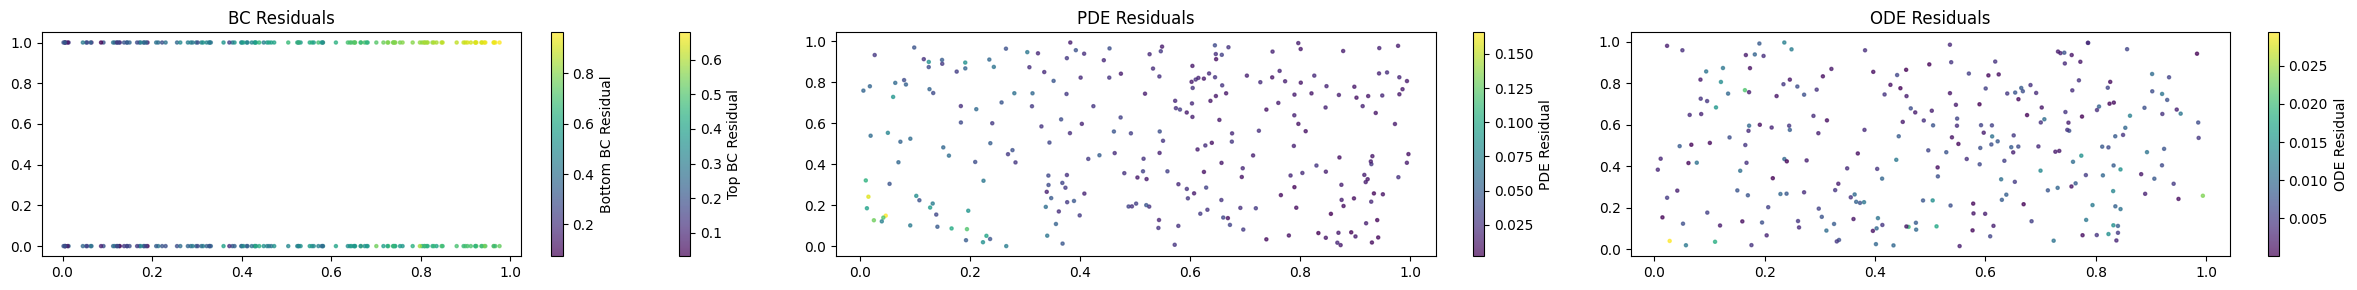

Training Progress:  40%|██████████████████████████████████████████████████████████████████████▊                                                                                                          | 20/50 [01:15<02:11,  4.40s/it, Status=** Training a **, Loss T=8.75e-03, Loss a=5.80e-03, ICs T=5.59e-04, ICs tool=2.43e-04, ICs Alpha=4.15e-05, BCs Bot=5.74e-04, BCs Top=6.65e-04, PDE Part=5.50e-04, PDE Tool=6.39e-04, Cure Part=5.75e-03, INF=3.26e-04, FLUX=2.35e-04, T lr=9.48e-04, a lr=9.48e-04]

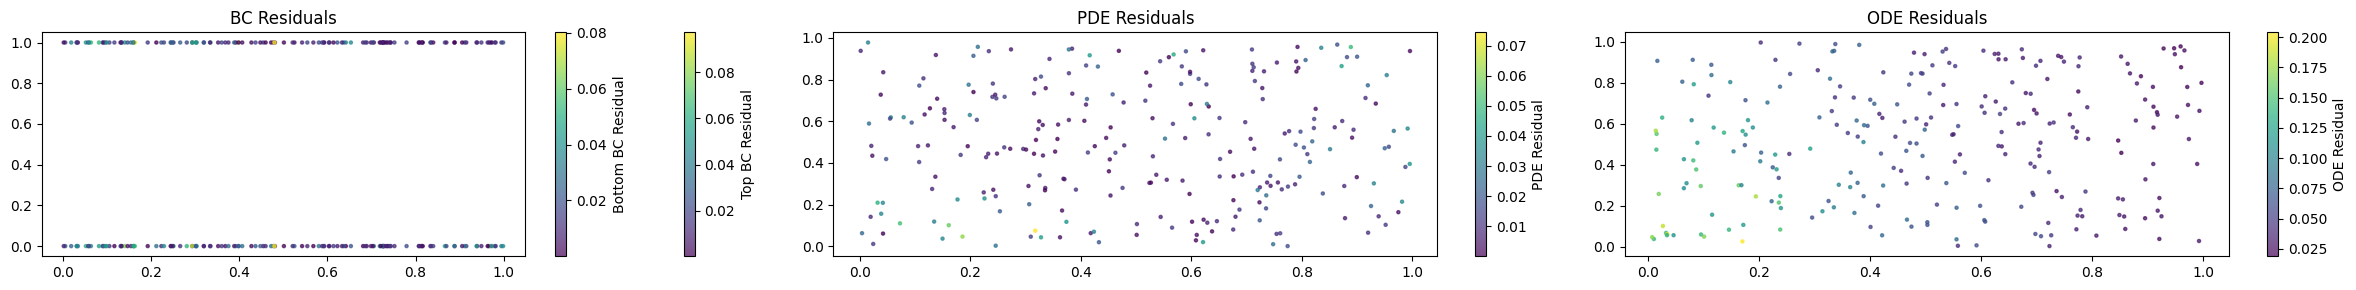

Training Progress:  60%|██████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                                                      | 30/50 [01:46<01:00,  3.01s/it, Status=** Training T **, Loss T=1.02e-02, Loss a=6.47e-05, ICs T=5.70e-04, ICs tool=4.49e-04, ICs Alpha=3.55e-05, BCs Bot=5.93e-04, BCs Top=8.87e-04, PDE Part=3.09e-04, PDE Tool=7.15e-04, Cure Part=2.92e-05, INF=4.72e-04, FLUX=3.33e-04, T lr=9.48e-04, a lr=8.99e-04]

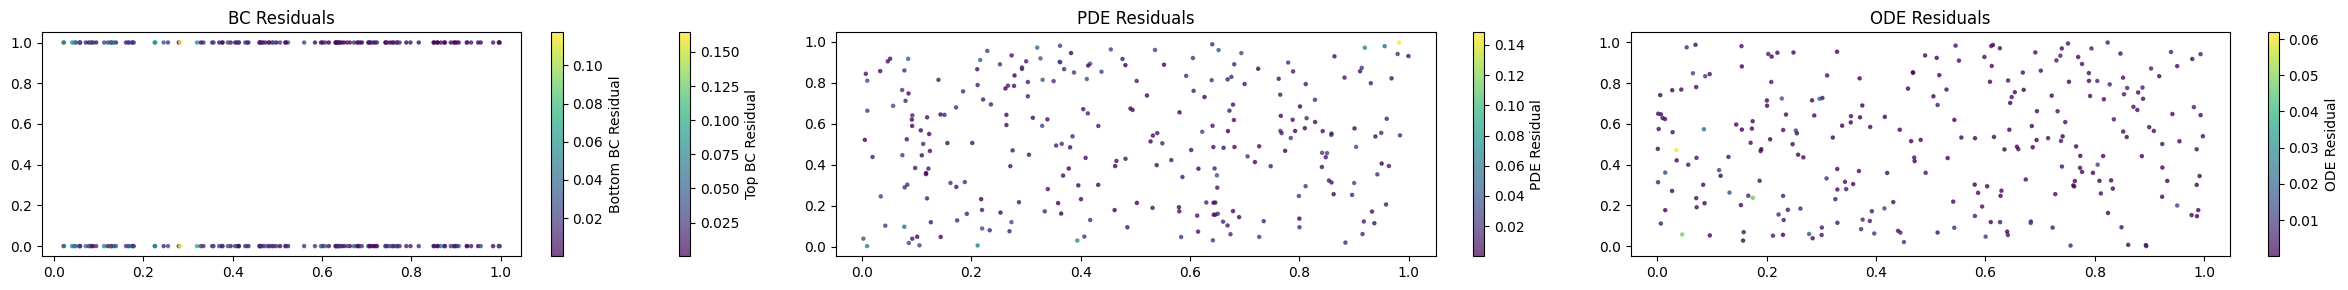

Training Progress:  80%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                   | 40/50 [02:30<00:43,  4.31s/it, Status=** Training a **, Loss T=4.94e-03, Loss a=1.11e-04, ICs T=8.08e-05, ICs tool=6.94e-05, ICs Alpha=1.65e-05, BCs Bot=3.60e-04, BCs Top=4.42e-04, PDE Part=1.76e-04, PDE Tool=2.47e-04, Cure Part=9.45e-05, INF=1.24e-04, FLUX=2.39e-04, T lr=8.99e-04, a lr=8.99e-04]

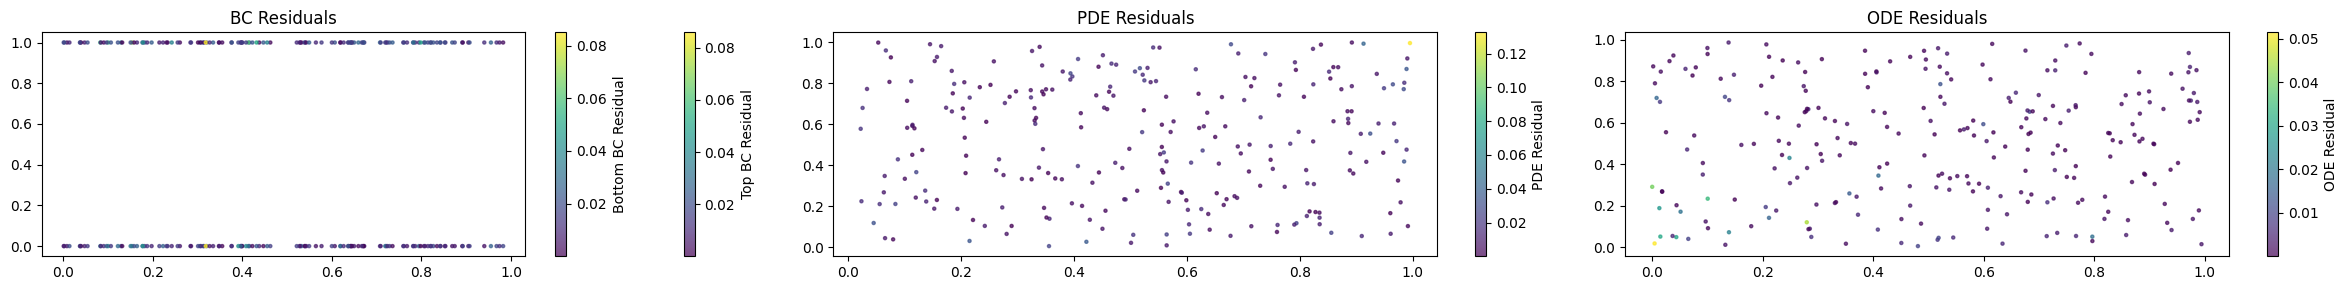

Training Progress: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [03:00<00:00,  3.62s/it, Status=** Training T **, Loss T=3.85e-03, Loss a=5.99e-05, ICs T=1.31e-04, ICs tool=7.35e-05, ICs Alpha=1.45e-05, BCs Bot=3.15e-04, BCs Top=2.37e-04, PDE Part=2.39e-04, PDE Tool=2.85e-04, Cure Part=4.53e-05, INF=1.44e-04, FLUX=2.13e-04, T lr=8.99e-04, a lr=8.52e-04]


Models saved for converged subdomain 0.80 - 1.00
Saved as xpidon_class_00_T.pkl and xpidon_class_00_a.pkl

Models saved for converged subdomain 0.80 - 1.00
Saved as outputs/models/xpidon_class_10000_T.pkl and outputs/models/xpidon_class_10000_a.pkl
Loss history saved as outputs/loss_data/loss_history_10000.pkl

--- Domain Decomposition Training Complete ---


In [6]:
train(XPIDON, XPIDONLoss, generate_training_data, DataGenerator, Temp_air,params,exp_params,train_params,init_sub_domain,Tolerance_level,m_inp,
          branch_layers ,trunk_layers, nomad_layers_T)

In [7]:
%run plot_training_results.py

Using loss files:
  outputs/loss_data/loss_history_02000.pkl
  outputs/loss_data/loss_history_04000.pkl
  outputs/loss_data/loss_history_06000.pkl
  outputs/loss_data/loss_history_08000.pkl
  outputs/loss_data/loss_history_10000.pkl

Merged loss length:
loss_T 200
loss_a 300
loss_ics_T 200
loss_ics_tool 200
loss_ics_a 300
loss_bct 200
loss_bcb 200
loss_res 200
loss_res_tool 200
loss_ode 300
loss_inf 200
loss_flux 200
Saved: outputs/loss_data/loss_history_merged.pkl
Saved: outputs/figures/temperature_network_loss.png
Saved: outputs/figures/doc_network_loss.png

Using model tags:
02000 outputs/models/xpidon_class_02000_T.pkl outputs/models/xpidon_class_02000_a.pkl
04000 outputs/models/xpidon_class_04000_T.pkl outputs/models/xpidon_class_04000_a.pkl
06000 outputs/models/xpidon_class_06000_T.pkl outputs/models/xpidon_class_06000_a.pkl
08000 outputs/models/xpidon_class_08000_T.pkl outputs/models/xpidon_class_08000_a.pkl
10000 outputs/models/xpidon_class_10000_T.pkl outputs/models/xpidon_cla

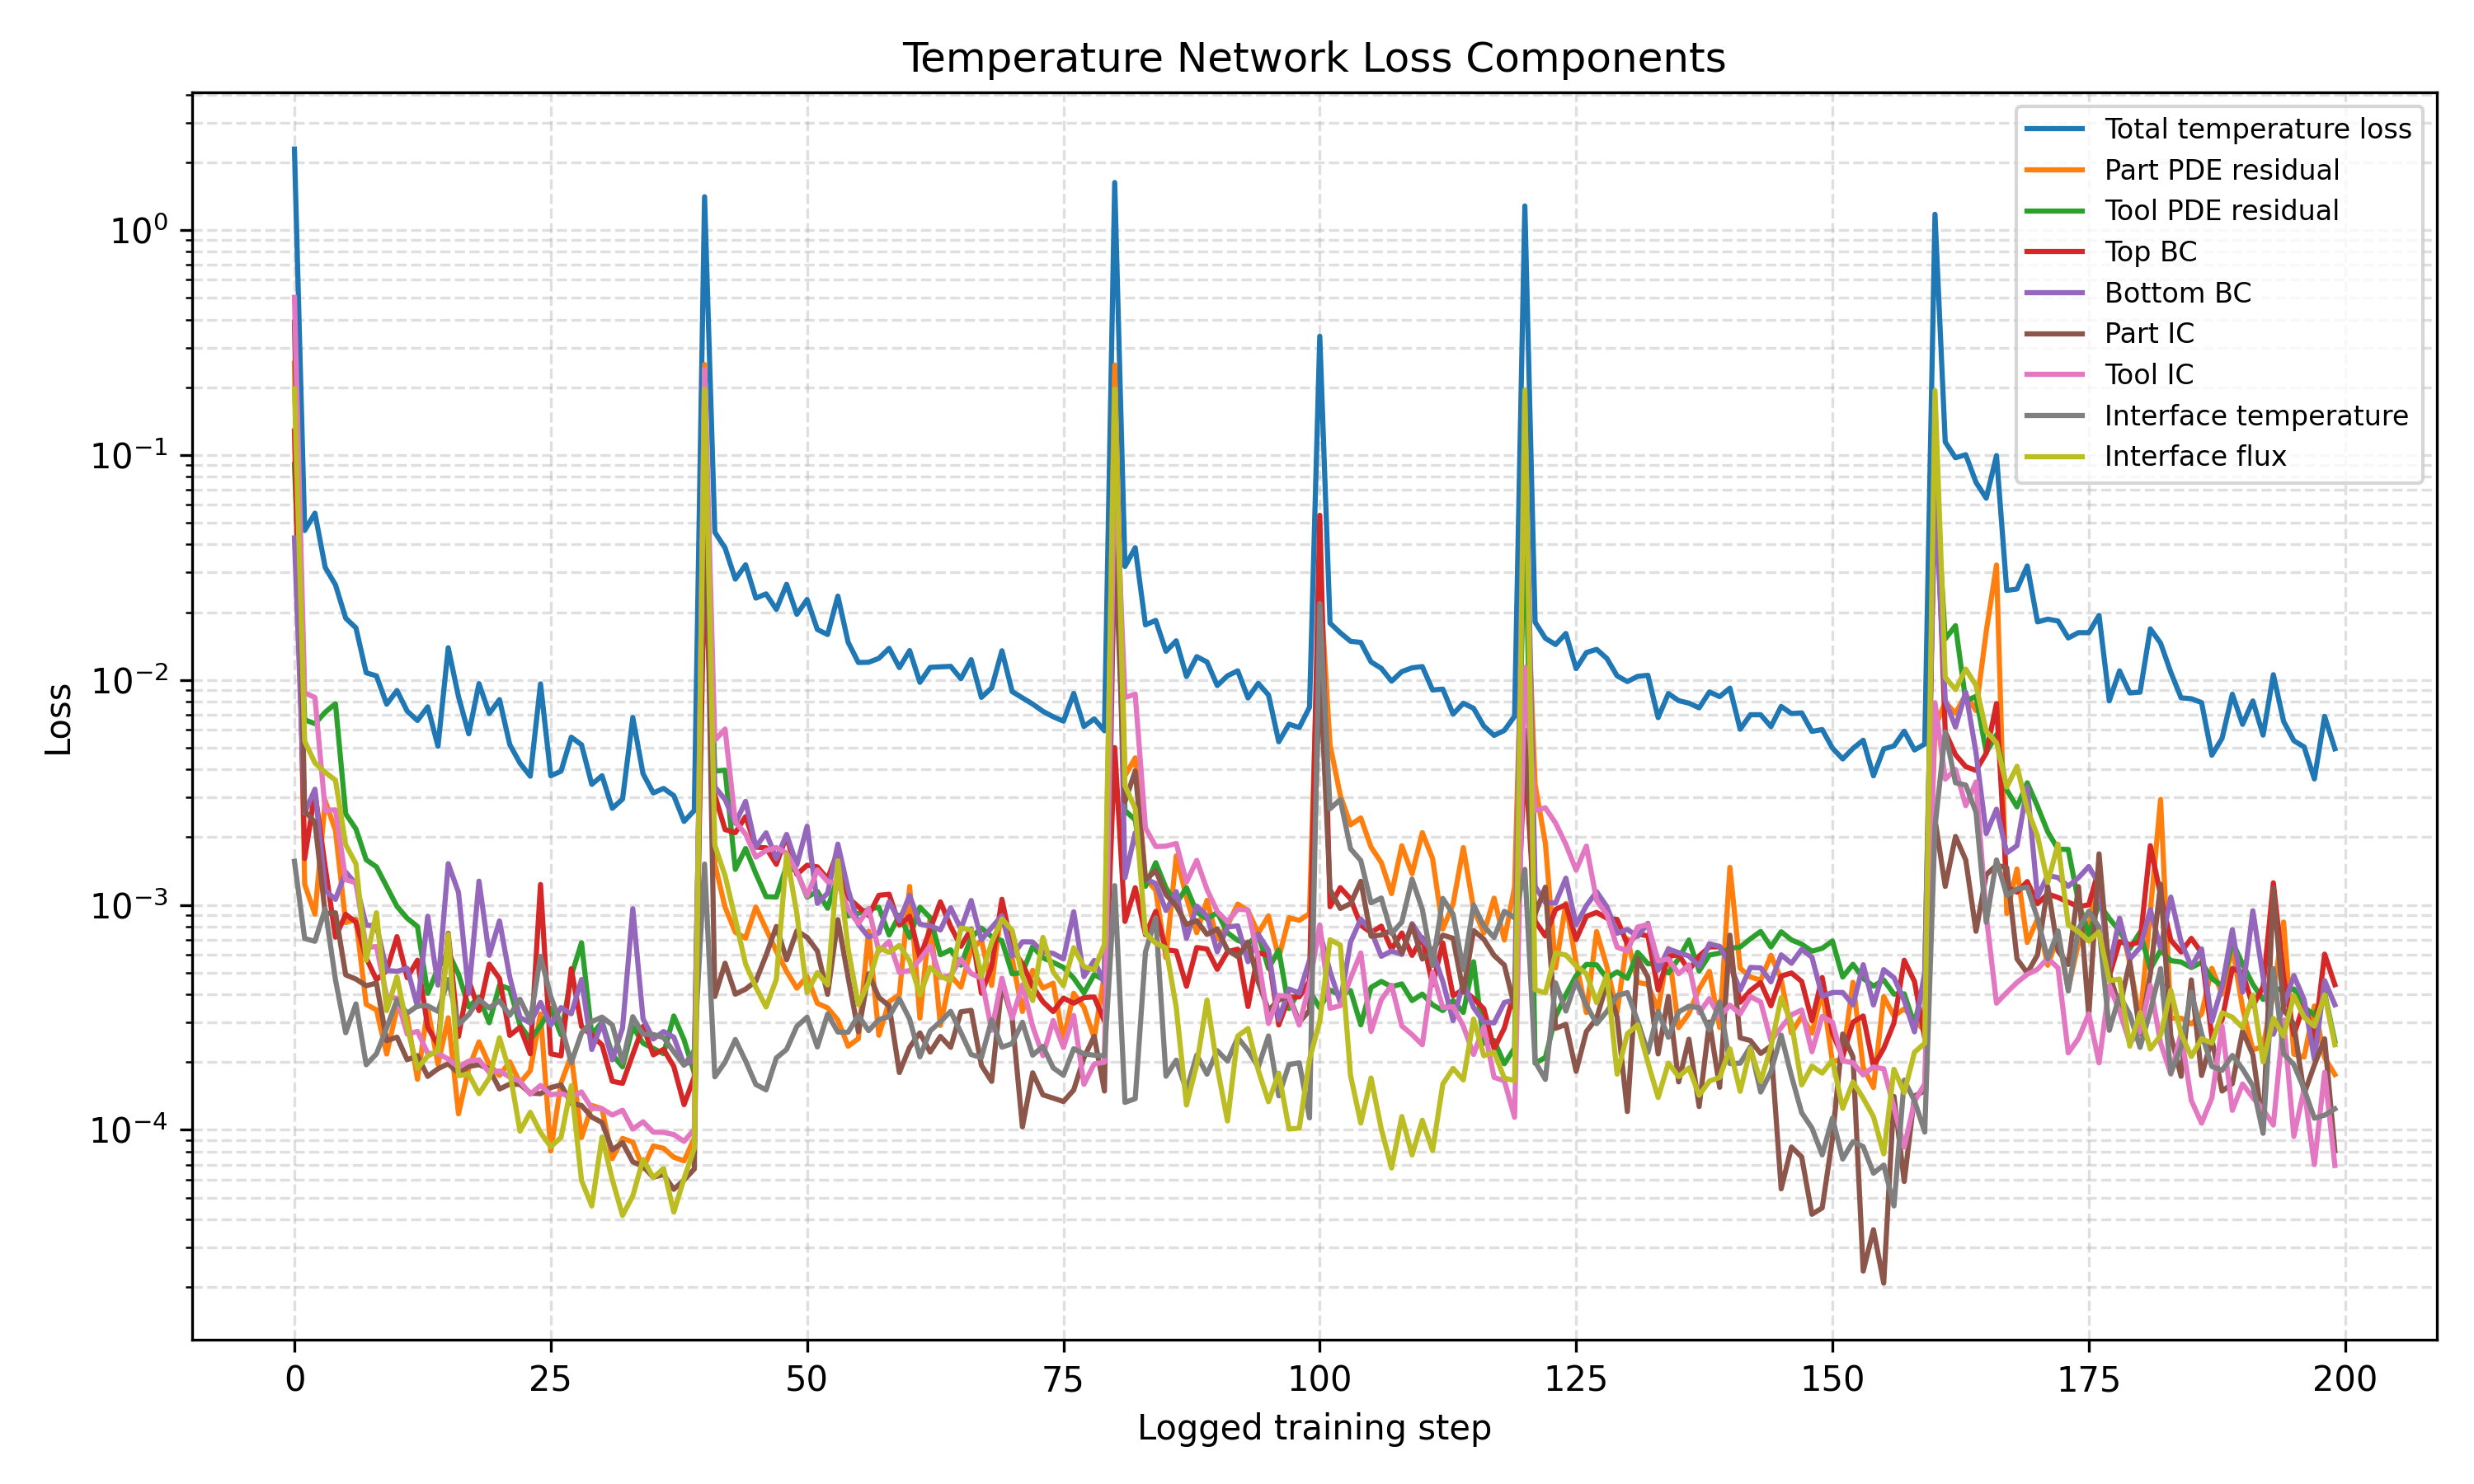

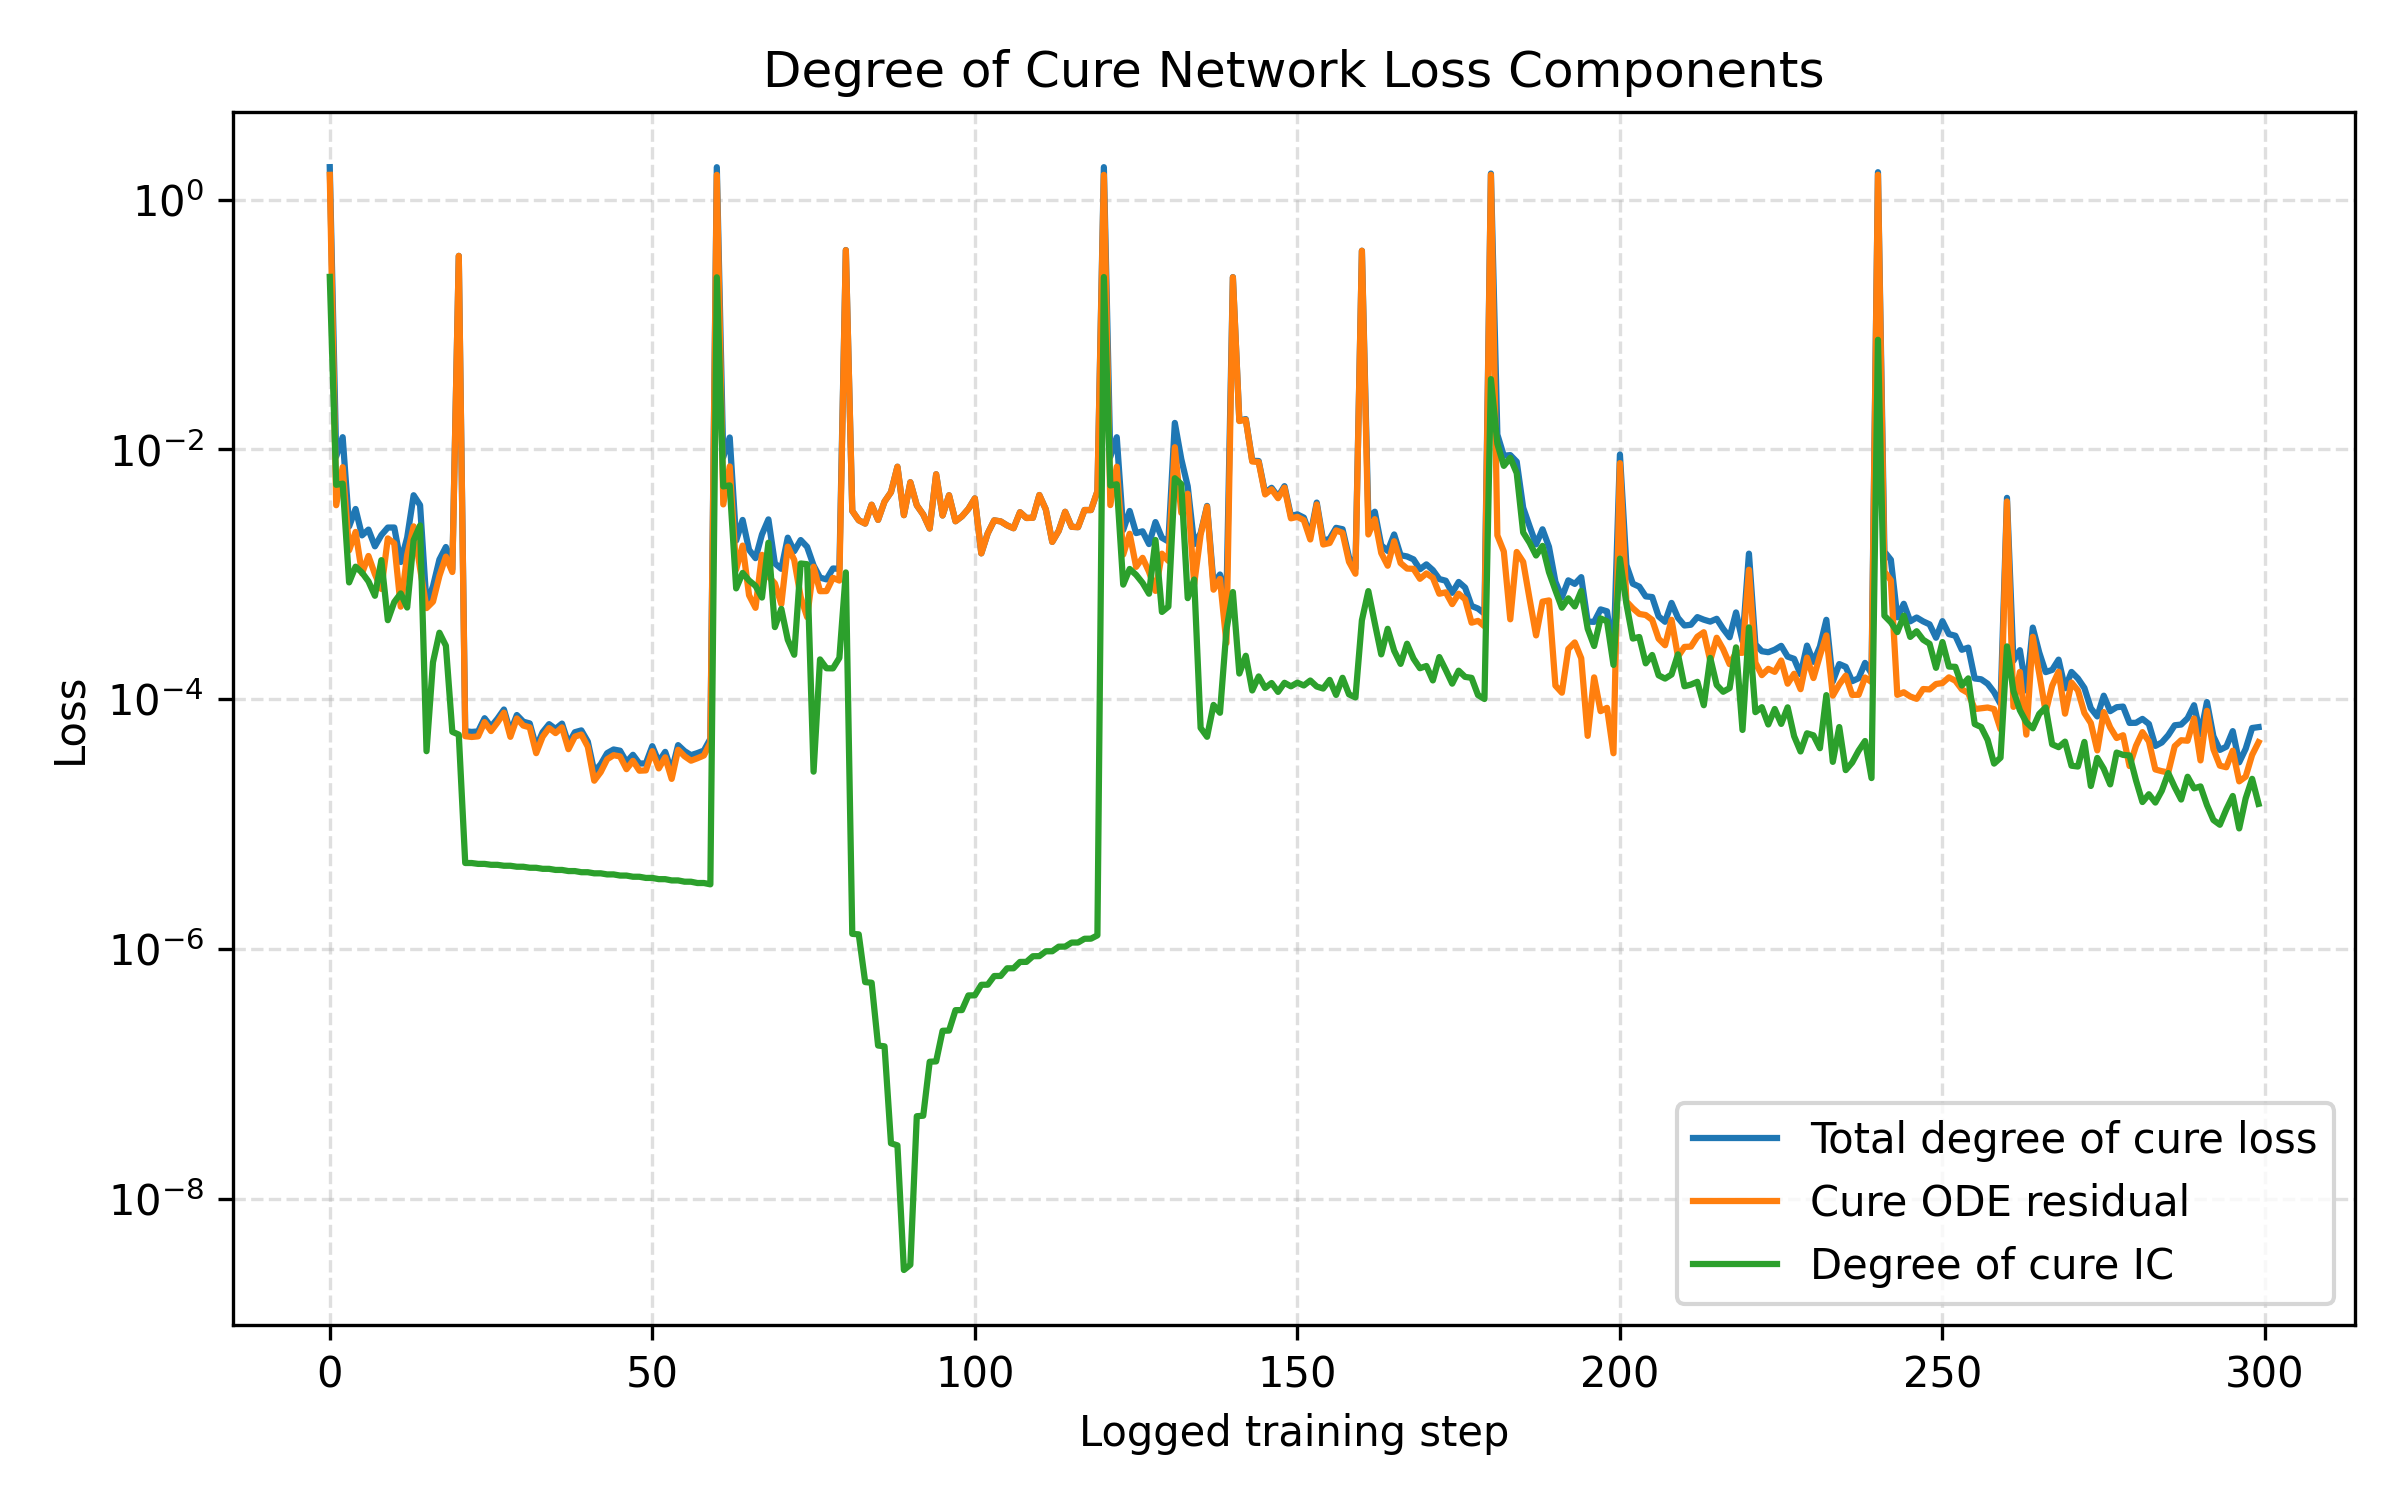

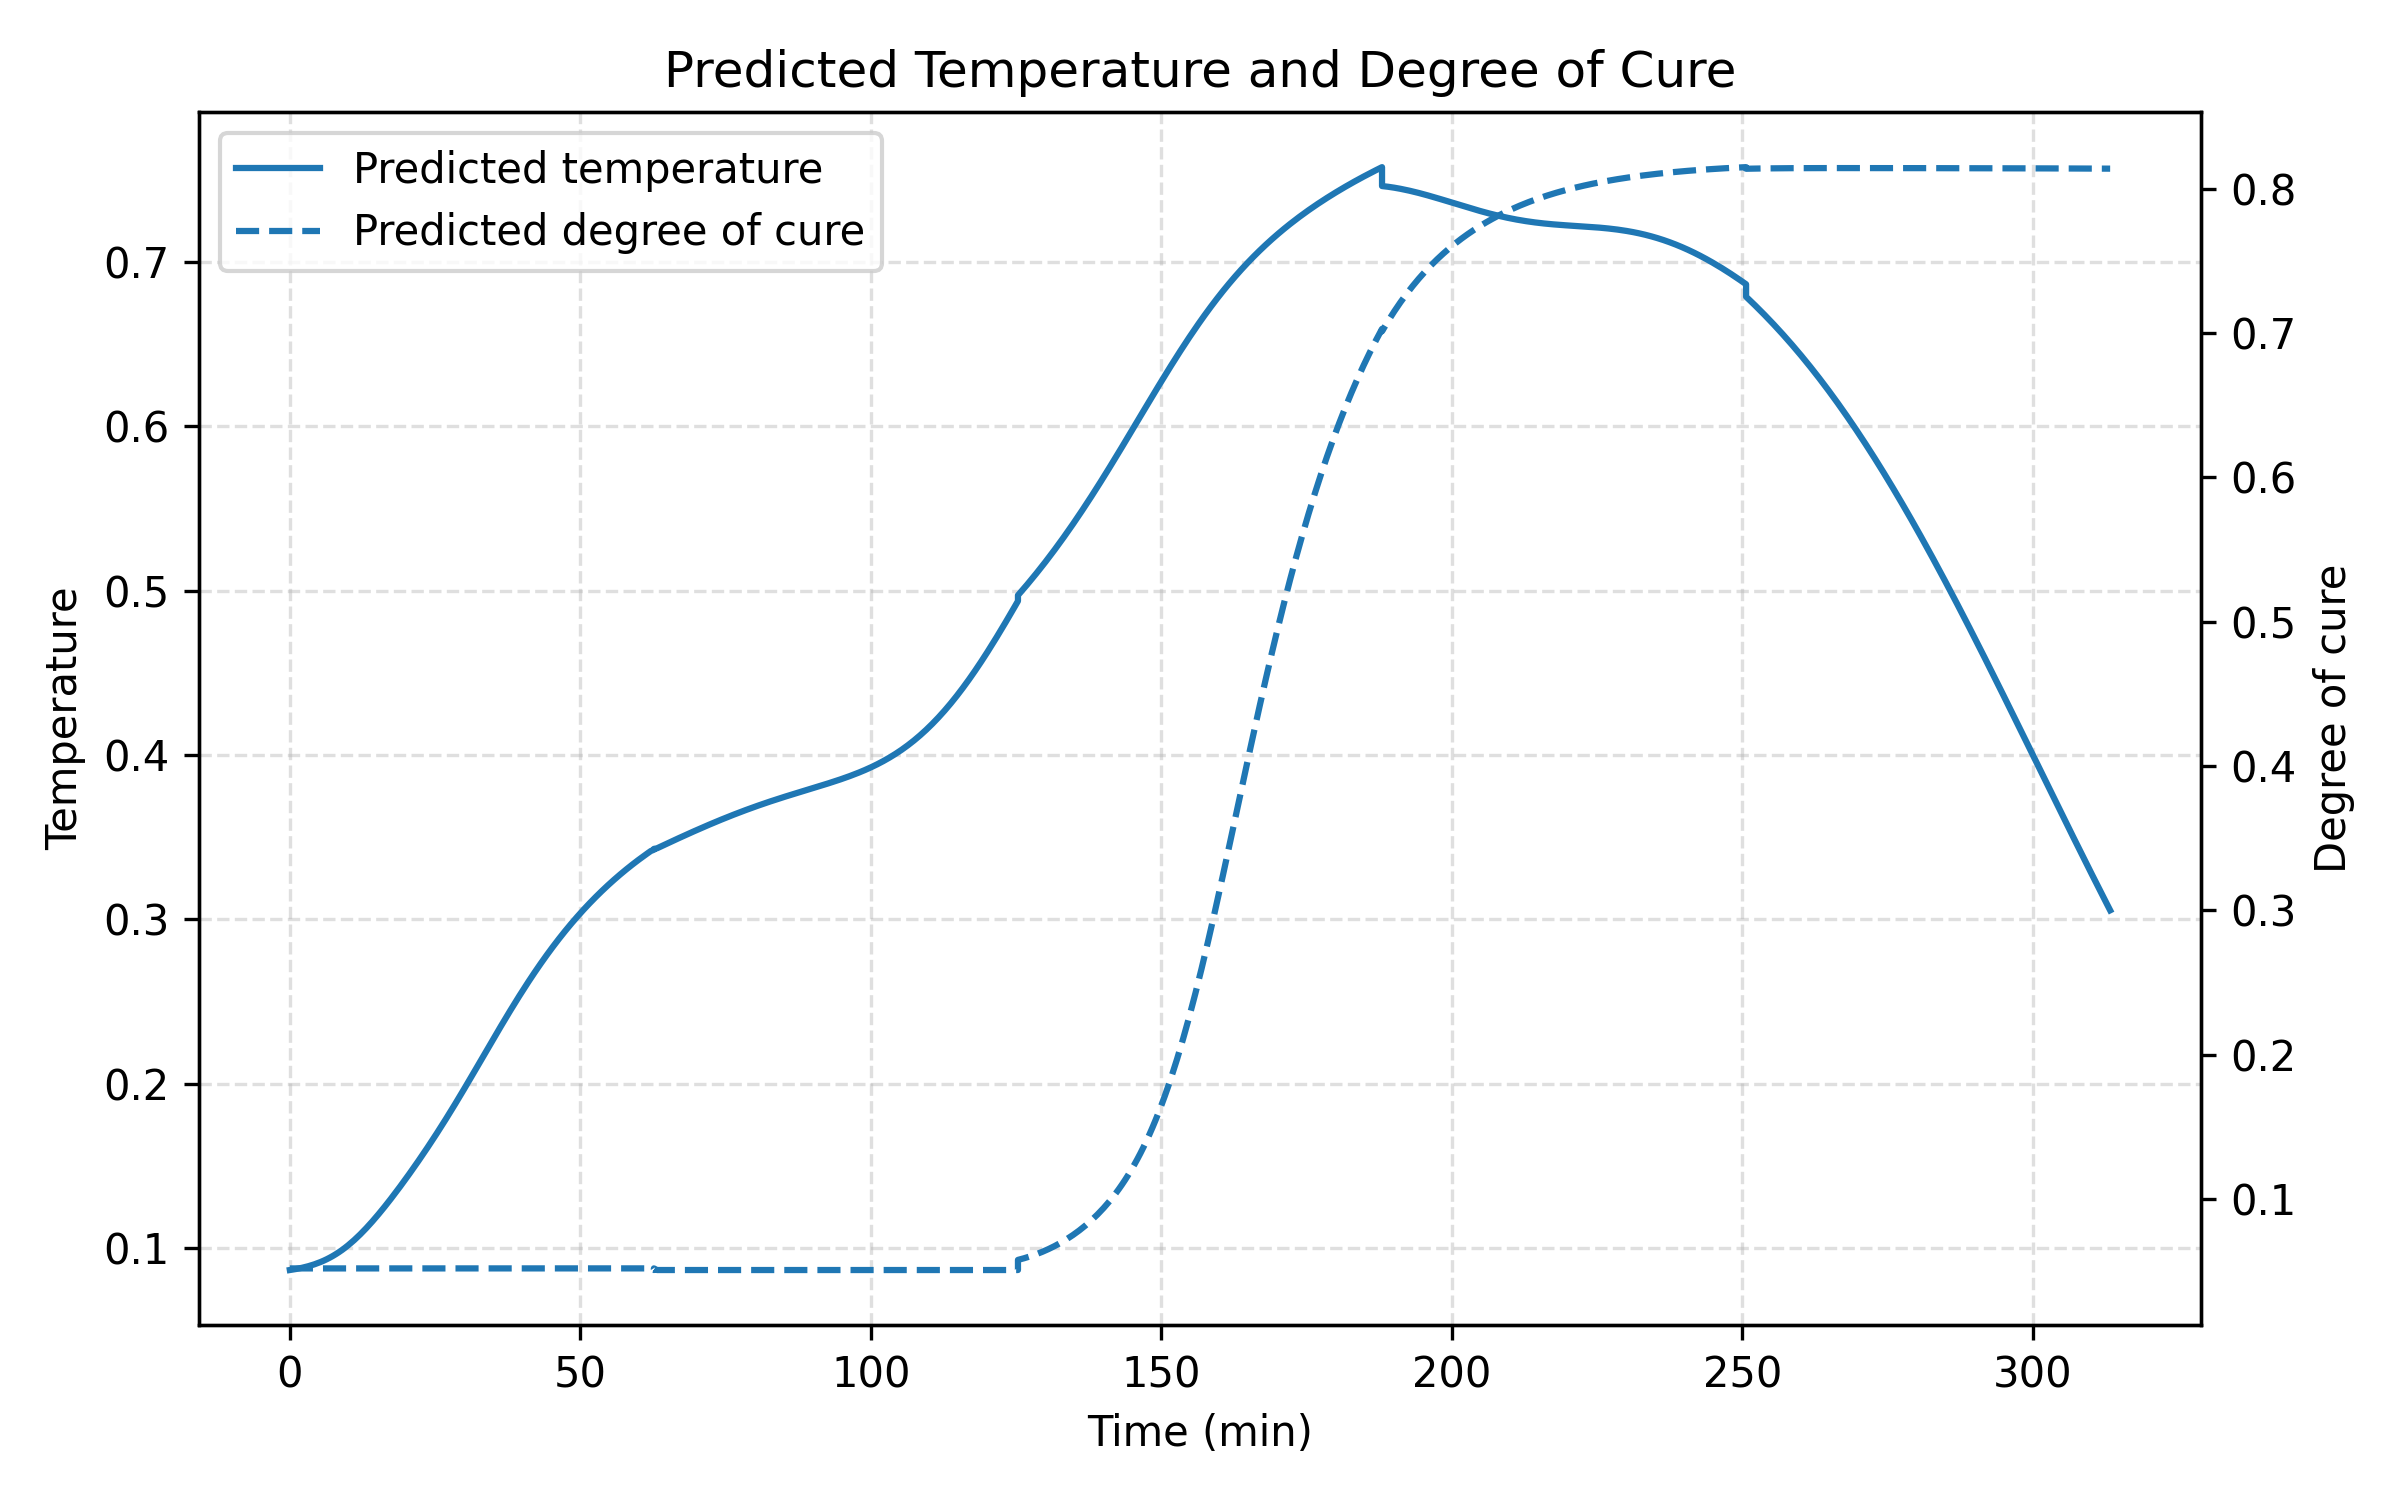

In [8]:

from IPython.display import Image, display

display(Image("outputs/figures/temperature_network_loss.png"))
display(Image("outputs/figures/doc_network_loss.png"))
display(Image("outputs/figures/final_temperature_doc_prediction.png"))